<a href="https://colab.research.google.com/github/AbirAbidi/Image-Enhancement/blob/main/Image_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import dataset

In [ ]:
!pip install kaggle

In [ ]:

import os
os.environ['KAGGLE_USERNAME'] = " "
os.environ['KAGGLE_KEY'] = ""

In [ ]:
!kaggle datasets download -d xuhangc/filmset

Dataset URL: https://www.kaggle.com/datasets/xuhangc/filmset
License(s): MIT
100% 10.4G/10.4G [01:29<00:00, 139MB/s]
100% 10.4G/10.4G [01:29<00:00, 124MB/s]


In [ ]:
!unzip -q filmset.zip -d /content/filmset/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mv /content/filmset /content/drive/MyDrive/filmset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p /content/filmset/train/Cinema
!mkdir -p /content/filmset/train/input

!cp -r /content/drive/MyDrive/filmset/FilmSet/train/Cinema/* /content/filmset/train/Cinema/

!cp -r /content/drive/MyDrive/filmset/FilmSet/train/input/* /content/filmset/train/input/

In [ ]:
!du -sh /content/filmset # to check size w bara

11G	/content/filmset


In [ ]:
!pip install pytorch-msssim

In [ ]:
!pip install tensorboard opencv-python

In [ ]:
import torchvision
import torch
import cv2
import matplotlib
import numpy as np
import tensorboard
import tqdm  # make loops show progress bar
import pandas as pd
import os
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from  torch.utils.data import DataLoader , Dataset
import torchvision.transforms as transforms
import glob
import pytorch_msssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim


## Explore Dataset

In [ ]:
dataset_dir = "/content/filmset/FilmSet/train"
#count + image sizes
#image resolution distribution

class_count = {}
image_size = []
resolutions = {}
total_images = 0
for class_name in os.listdir(dataset_dir):
  class_path = os.path.join(dataset_dir,class_name)
  if os.path.isdir(class_path):
    total_images +=  len(os.listdir(class_path))
    for file in os.listdir(class_path):
      img_path = os.path.join(class_path,file)
      #hethi ll image sizes
      img = Image.open(img_path)
      size = img.size  # hethi traja3 width,height
      image_size.append(size)
      #hethi ll resolution
      if size in resolutions:
        resolutions[size] += 1
      else :
        resolutions[size] = 1


print("Total images: ",total_images)
print("Image sizes: ",image_size[:10])
print("Image resolutions: ", resolutions)

Total images:  18628
Image sizes:  [(512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512)]
Image resolutions:  {(512, 512): 18628}


In [ ]:
# hethi FFT : frequency domain (fast fourier transform)
#detects noise levels , blur, repetitve textures, compression artifacts

dataset_dir = "/content/filmset/FilmSet/train"
spectra = []
for class_name in os.listdir(dataset_dir):
  class_path = os.path.join(dataset_dir,class_name)
  for file in os.listdir(class_path):
    if file.lower().endswith((".jpg", ".jpeg", ".png")): # endswith accepts tuples so  endswith((".jpg", ".jpeg", ".png"))  not endswith(".jpg", ".jpeg", ".png")
      img = Image.open(os.path.join(class_path,file)).convert("L") #grayscale
      arr = np.array(img)
      #do 2d fourier transform
      fshift = np.fft.fftshift(np.fft.fft2(arr))
      # hethi np.fft.fft2(arr) thiz arr mil spatial domain ll frequency domain
      #hethi np.fft.fftshift  t9arib low freq to the middle
      magnitude = np.log(np.abs(fshift)) # magnitude spectra and log bech spec wont be dominated with low freq
      spectra.append(magnitude)
avg_spectra = np.mean(np.array(spectra),axis=0)
plt.imshow(avg_spectra,cmap="gray")
plt.axis("off")
plt.show()


KeyboardInterrupt: 

Baseline Model Purpose :

Before trying fancy “multi-frequency” methods, you first need a strong baseline.

A baseline is your reference model — something simple but solid.

Later, if your new method improves on the baseline, you can prove your innovation actually helps.
You feed the raw image as input. The U-Net outputs an enhanced version (e.g., denoised, sharpened, or super-resolved).

Loss = L1 + SSIM :
1.   Loss function guides the network to improve.
2.   L1 loss (mean absolute error):
  *   Penalizes pixel-wise differences.
  *   Good for overall brightness and structure.
3.   SSIM (Structural Similarity Index) loss:
  *   Penalizes structural/texture differences.
  *   Encourages the output to look perceptually similar to the target image.
4.  Combining L1 + SSIM ensures both pixel accuracy and visual quality.

Train for 20/30 epochs.

After training, evaluate your model with metrics:
1. PSNR (Peak Signal-to-Noise Ratio)
* Measures overall fidelity between enhanced and ground-truth images.
* Higher PSNR → better reconstruction.
2. SSIM (Structural Similarity Index)
* Measures structural similarity.
* Higher SSIM → better preservation of edges, textures, and perceptual quality.

## Standard U-Net


In [ ]:
#defining UNet model
class UNet(nn.Module):
  def __init__(self,in_channel=1,out_channel=1,features=[64,128,256,512]):
    super(UNet,self).__init__()
    self.downs = nn.ModuleList()
    self.ups = nn.ModuleList()
    self.pool = nn.MaxPool2d(kernel_size=2,stride=2)

    for feature in features :
      self.downs.append(self.conv_block(in_channel,feature))
      in_channel = feature

    for feature in reversed(features):
      self.ups.append(
          nn.ConvTranspose2d(feature*2,feature,kernel_size=2,stride=2)
      )
      self.ups.append(self.conv_block(feature*2,feature))

      self.bottleneck = self.double_conv(features[-1],features[-1]*2)
      self.final_conv = nn.Conv2d(features[0],out_channel,kernel_size=1)
  def double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

  def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = torch.nn.functional.interpolate(x, size=skip_connection.shape[2:])
            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](x)

        return self.final_conv(x)

class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, img  # input = target for baseline enhancement

transform = transforms.Compose([
    transforms.ToTensor(),  # convert to [0,1]
])

train_paths = glob.glob("/content/filmset/FilmSet/train/Cinema/*.png")
train_dataset = ImageDataset(train_paths, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)


l1_loss = nn.L1Loss()

def combined_loss(pred, target):
    ssim_loss = 1 - pytorch_msssim.ssim(pred, target, data_range=1.0, size_average=True)
    return l1_loss(pred, target) + ssim_loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
epochs = 20

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = combined_loss(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

In [ ]:
model.eval()
psnr_values = []
ssim_values = []

for inputs, targets in train_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    with torch.no_grad():
        outputs = model(inputs)
    outputs_np = outputs.cpu().numpy()
    targets_np = targets.cpu().numpy()
    for o, t in zip(outputs_np, targets_np):
        o = o.squeeze()
        t = t.squeeze()
        psnr_values.append(psnr(t, o, data_range=1))
        ssim_values.append(ssim(t, o, data_range=1))
print("Average PSNR:", np.mean(psnr_values))
print("Average SSIM:", np.mean(ssim_values))

## laplacian pyramid decomposition

In [ ]:
def gaussian_pyramid(image,num_levels=4):
  gauss_pyramid = [image]
  for i in range(num_levels-1):
    image = cv2.pyrDown(image) #blurs + traja3 list of smaller resolution each time
    gauss_pyramid.append(image)
  return gauss_pyramid

def laplacian_pyramid(image,num_levels=4):
    gauss_pyramid = gaussian_pyramid(image,num_levels)
    laplacian_pyramid = []
    for i in range(num_levels-1):
      upsampled = cv2.pyrUp(gauss_pyramid[i+1])
      # laplacien = current level - upsamled next level
      laplacian = cv2.subtract(gauss_pyramid[i],upsampled)
      laplacian_pyramid.append(laplacian)
    laplacian_pyramid.append(gauss_pyramid[-1])
    return laplacian_pyramid

def reconstruct_from_laplacian(laplacian_pyramid):
    levels = len(laplacian_pyramid)
    img = laplacian_pyramid[-1]  # start from lowest resolution
    for i in range(levels-2, -1, -1):
        size = (laplacian_pyramid[i].shape[1], laplacian_pyramid[i].shape[0])
        img = cv2.pyrUp(img, dstsize=size) + laplacian_pyramid[i]
    return img

image = cv2.imread('/content/filmset/FilmSet/test/Cinema/DSCF7071.png')[:,:,::-1].astype(np.float32) / 255.0  # BGR → RGB
lp = laplacian_pyramid(image, 4)
reconstructed = reconstruct_from_laplacian(lp)

print("Reconstruction error:", np.abs(image.astype(np.float32)-reconstructed).mean())


Reconstruction error: 1.38769e-11


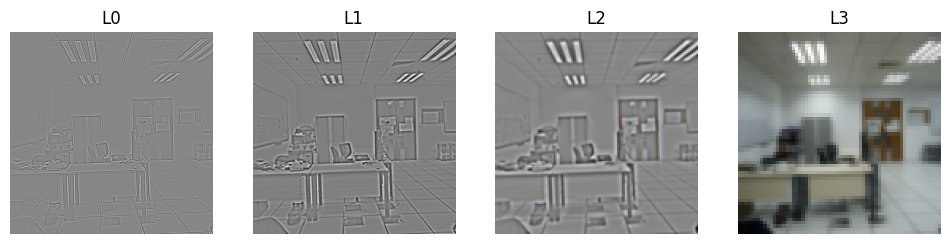

In [ ]:
plt.figure(figsize=(12,4))
for i, level in enumerate(lp):
    plt.subplot(1, len(lp), i+1)
    # Normalize for visualization
    vis = level.astype(np.float32)  # convert to float
    vis = vis - vis.min()
    vis = vis / vis.max()
    plt.imshow(vis)
    plt.title(f"L{i}")
    plt.axis('off')
plt.show()

## CNN

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_layers=5):
        super().__init__()

        layers = []

        # First convolution layer
        # Takes input image (3 channels RGB)
        # Outputs 64 feature maps
        layers.append(nn.Conv2d(in_channels, 64, kernel_size=3, padding=1))
        layers.append(nn.ReLU())

        # Middle convolution layers
        # Each layer:
        # - Slides 64 filters over feature maps
        # - Detects spatial patterns (edges, textures, etc.)
        for _ in range(num_layers - 2):
            layers.append(nn.Conv2d(64, 64, kernel_size=3, padding=1))
            layers.append(nn.ReLU())

        # Final convolution
        # Reduces 64 feature maps back to 3 channels (RGB)
        layers.append(nn.Conv2d(64, out_channels, kernel_size=3, padding=1))

        # Combine all layers into one sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # x shape: (B, 3, H, W)  : meaning (Batch size, Channels, Height, Width)
        return self.model(x)

In [ ]:
import torch.nn.functional as F

In [ ]:
class FrequencyEnhancementNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Three frequency branches
        self.cnn_low = SimpleCNN(num_layers=5)
        self.cnn_mid = SimpleCNN(num_layers=5)
        self.cnn_high = SimpleCNN(num_layers=3)

        # Fusion layer
        self.fusion = nn.Conv2d(9, 3, kernel_size=1)

    # ----------------------------------------
    # Torch Laplacian Decomposition
    # ----------------------------------------
    def laplacian_decompose(self, x):
        """
        x shape: (B,3,H,W)
        Returns: low, mid, high
        """

        # Downsample (low frequency)
        low = F.interpolate(x, scale_factor=0.5, mode='bilinear', align_corners=False)

        # Upsample back to original size
        low_upsampled = F.interpolate(low, size=x.shape[2:], mode='bilinear', align_corners=False)

        # High frequency = original - blurred
        high = x - low_upsampled

        # For simplicity:
        # mid = low_upsampled (smooth component)
        mid = low_upsampled

        return low_upsampled, mid, high

    def forward(self, x):
        """
        x shape: (B,3,H,W)
        """

        # --------------------------------
        #  Decompose image
        # --------------------------------
        low, mid, high = self.laplacian_decompose(x)

        # --------------------------------
        #  Process each band
        # --------------------------------
        out_low = self.cnn_low(low)
        out_mid = self.cnn_mid(mid)
        out_high = self.cnn_high(high)

        # --------------------------------
        #  Concatenate
        # --------------------------------
        fused = torch.cat([out_low, out_mid, out_high], dim=1)

        # --------------------------------
        #  Frequency Fusion
        # --------------------------------
        output = self.fusion(fused)

        return output

In [ ]:
model = FrequencyEnhancementNet()
input_image = torch.randn(4, 3, 256, 256)

output = model(input_image)

print(output.shape)

torch.Size([4, 3, 256, 256])


In [ ]:
from PIL import Image

class FilmEnhancementDataset(Dataset):
    def __init__(self, input_dir, target_dir, transform=None):
        self.input_paths = sorted([os.path.join(input_dir, f) for f in os.listdir(input_dir)])
        self.target_paths = sorted([os.path.join(target_dir, f) for f in os.listdir(target_dir)])
        self.transform = transform

    def __len__(self):
        return len(self.input_paths)

    def __getitem__(self, idx):
        # Load images with PIL
        input_img = Image.open(self.input_paths[idx]).convert("RGB")
        target_img = Image.open(self.target_paths[idx]).convert("RGB")

        # Apply transforms (resize, tensor, normalization)
        if self.transform:
            input_img = self.transform(input_img)
            target_img = self.transform(target_img)

        return input_img, target_img

In [ ]:
from torchvision import transforms

# Define transforms: resize to 128x128 and convert to tensor
transform = transforms.Compose([
    transforms.ToPILImage(),             # convert numpy array (from cv2) to PIL Image
    transforms.Resize((128, 128)),       # resize
    transforms.ToTensor()                # convert to tensor [0,1]
])

# Update your Dataset to accept transforms
train_dataset = FilmEnhancementDataset(
    input_dir="/content/filmset/train/input",
    target_dir="/content/filmset/train/Cinema",
    transform=transform                   # pass the transform
)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=1,
    pin_memory=True
)

In [ ]:
num_workers = os.cpu_count()  # total CPU cores available
print("CPU cores:", num_workers)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=num_workers//2)

CPU cores: 2


In [ ]:
from tqdm import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FrequencyEnhancementNet().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 10

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    # tqdm will show a progress bar for the batches
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}")
    for batch_idx, (inputs, targets) in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = criterion(outputs, targets)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Update tqdm bar with batch loss
        loop.set_postfix(batch_loss=loss.item(), avg_loss=epoch_loss/(batch_idx+1))

    print(f"Epoch {epoch+1}/{epochs}, Average Loss: {epoch_loss/len(train_loader):.4f}")

Epoch 1/10: 100%|██████████| 1165/1165 [02:57<00:00,  6.58it/s, avg_loss=0.0307, batch_loss=0.00883]

Epoch 1/10, Average Loss: 0.0307



Epoch 2/10: 100%|██████████| 1165/1165 [02:46<00:00,  7.01it/s, avg_loss=0.0116, batch_loss=0.00675]


Epoch 2/10, Average Loss: 0.0116


Epoch 3/10: 100%|██████████| 1165/1165 [02:38<00:00,  7.35it/s, avg_loss=0.0104, batch_loss=0.00447]

...

Epoch 8/10, Average Loss: 0.0091



Epoch 9/10: 100%|██████████| 1165/1165 [02:39<00:00,  7.32it/s, avg_loss=0.00921, batch_loss=0.00887]

Epoch 9/10, Average Loss: 0.0092



Epoch 10/10: 100%|██████████| 1165/1165 [02:41<00:00,  7.20it/s, avg_loss=0.00897, batch_loss=0.00495]

Epoch 10/10, Average Loss: 0.0090


In [ ]:
torch.save(model.state_dict(), "/content/filmset/frequency_enhancement_net.pth")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/filmset_models

torch.save(model.state_dict(), "/content/drive/MyDrive/filmset_models/frequency_enhancement_net.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# reload model later

model = FrequencyEnhancementNet().to(device)
model.load_state_dict(torch.load("/content/filmset/frequency_enhancement_net.pth"))
model.eval()

FrequencyEnhancementNet(
  (cnn_low): SimpleCNN(
    (model): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (cnn_mid): SimpleCNN(
    (model): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): Conv2d(64, 3, kernel_s

## Test

In [ ]:
!mkdir -p /content/filmset/test/Cinema
!mkdir -p /content/filmset/test/input

!cp -r /content/drive/MyDrive/filmset/FilmSet/test/Cinema/* /content/filmset/test/Cinema/

!cp -r /content/drive/MyDrive/filmset/FilmSet/test/input/* /content/filmset/test/input/

In [ ]:
from torch.utils.data import DataLoader

test_dataset = FilmEnhancementDataset(
    input_dir="/content/filmset/test/input",
    target_dir="/content/filmset/test/Cinema",
    transform=transforms.Compose([
        transforms.Resize((128, 128)),  # same as training
        transforms.ToTensor()
    ])
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=1
)

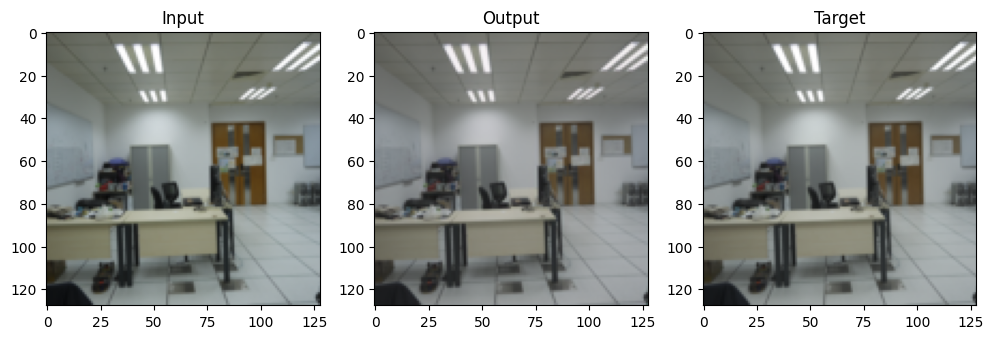

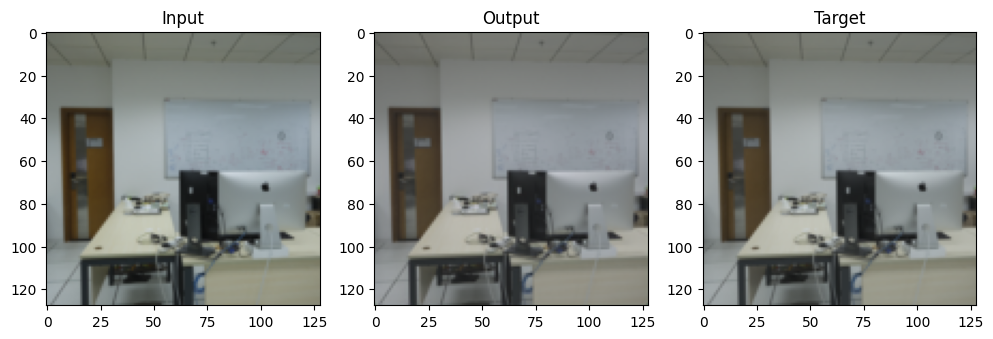

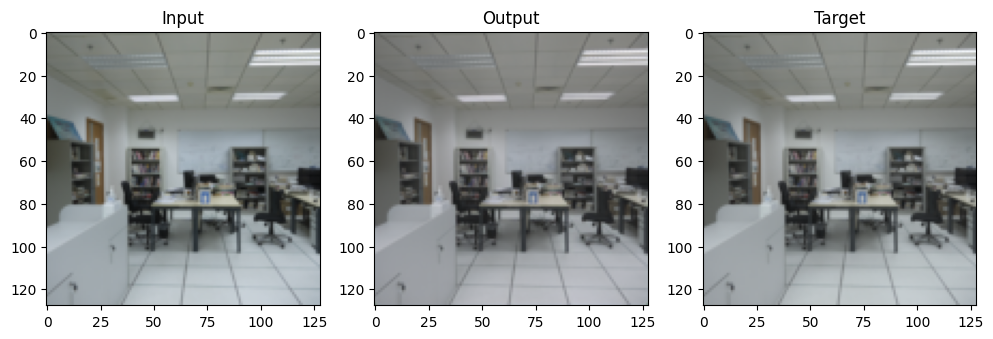

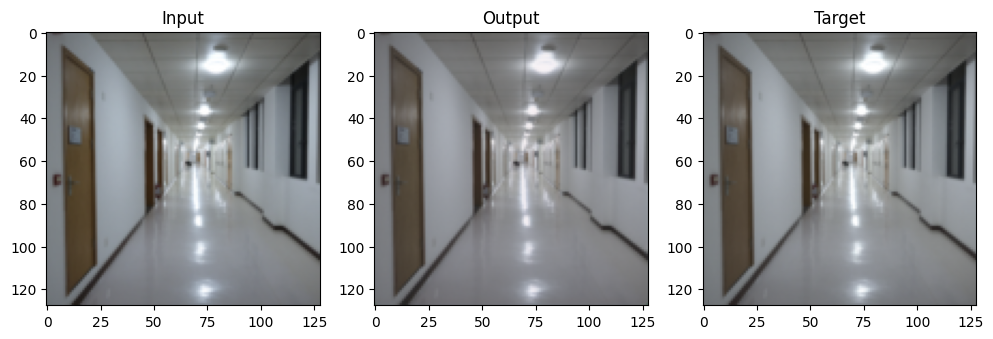

Average Test Loss: 0.01247220702326981


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

criterion = nn.L1Loss()
total_loss = 0

for i, (inputs, targets) in enumerate(test_loader):
    inputs, targets = inputs.to(device), targets.to(device)

    with torch.no_grad():  # no gradients needed for inference
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item()

    # Show first batch as example
    if i == 0:
        inputs_np = inputs.cpu().numpy()
        outputs_np = outputs.cpu().numpy()
        targets_np = targets.cpu().numpy()

        for j in range(min(4, inputs_np.shape[0])):
            fig, axs = plt.subplots(1, 3, figsize=(12,4))
            axs[0].imshow(np.transpose(inputs_np[j], (1,2,0)))
            axs[0].set_title("Input")
            axs[1].imshow(np.transpose(outputs_np[j], (1,2,0)))
            axs[1].set_title("Output")
            axs[2].imshow(np.transpose(targets_np[j], (1,2,0)))
            axs[2].set_title("Target")
            plt.show()

print("Average Test Loss:", total_loss / len(test_loader))

## Final Test

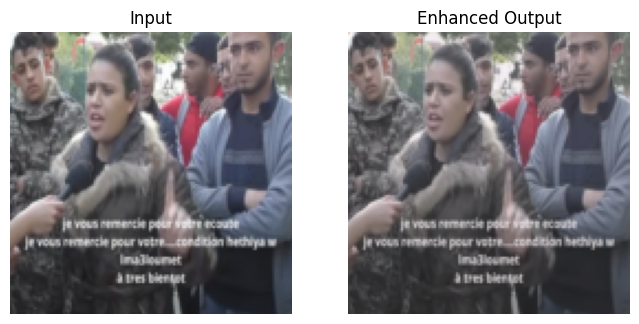

True

In [ ]:
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1️⃣ Load your trained model
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FrequencyEnhancementNet().to(device)
model.load_state_dict(torch.load("/content/filmset/frequency_enhancement_net.pth", map_location=device))
model.eval()

# -----------------------------
# 2️⃣ Define the transform
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # match training size
    transforms.ToTensor()
])

# -----------------------------
# 3️⃣ Load and preprocess your image
# -----------------------------
image_path = "/content/9os.png"  # replace with your image path
input_img = Image.open(image_path).convert("RGB")
input_tensor = transform(input_img).unsqueeze(0).to(device)  # add batch dimension

# -----------------------------
# 4️⃣ Inference
# -----------------------------
with torch.no_grad():
    output_tensor = model(input_tensor)

# -----------------------------
# 5️⃣ Convert tensors back to images for display
# -----------------------------
def tensor_to_image(tensor):
    tensor = tensor.squeeze(0).cpu().clamp(0,1)  # remove batch dim & clamp
    return np.transpose(tensor.numpy(), (1,2,0))  # C,H,W -> H,W,C

output_img = tensor_to_image(output_tensor)
input_img_np = tensor_to_image(input_tensor)

# -----------------------------
# 6️⃣ Display
# -----------------------------
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(input_img_np)
plt.title("Input")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output_img)
plt.title("Enhanced Output")
plt.axis('off')
plt.show()

cv2.imwrite("/content/output_img.png", (output_img*255).astype(np.uint8)[:,:,::-1])  # RGB -> BGR for saving

L1 Loss: 0.0184, PSNR: 32.57, SSIM: 0.9913


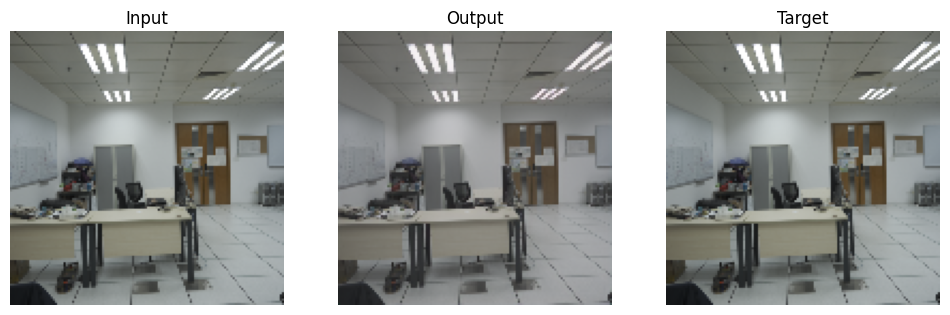

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.util import img_as_float32

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FrequencyEnhancementNet().to(device)
model.load_state_dict(torch.load("/content/filmset/frequency_enhancement_net.pth", map_location=device))
model.eval()

# Function to load and preprocess a single image
def load_image(path, size=(128,128)):
    img = cv2.imread(path)[:,:,::-1].astype(np.float32) / 255.0  # BGR->RGB
    img = cv2.resize(img, size)
    tensor = torch.from_numpy(img.transpose(2,0,1)).unsqueeze(0).to(device)  # (1,C,H,W)
    return tensor, img

# Paths
input_path = "/content/filmset/test/Cinema/DSCF7071.png"
target_path = "/content/filmset/test/Cinema/DSCF7071.png"

# Load images
input_tensor, input_img = load_image(input_path)
target_tensor, target_img = load_image(target_path)

# Inference
with torch.no_grad():
    output_tensor = model(input_tensor)

# Convert to NumPy
output_img = output_tensor.squeeze(0).cpu().numpy().transpose(1,2,0)
output_img = np.clip(output_img, 0, 1)

# Metrics
l1_loss = torch.nn.functional.l1_loss(output_tensor, target_tensor).item()
psnr_val = psnr(target_img, output_img, data_range=1.0)

# For SSIM, ensure proper data_range and channel_axis
target_float = img_as_float32(target_img)
output_float = img_as_float32(output_img)
min_dim = min(target_float.shape[:2])
win_size = 7 if min_dim >= 7 else (min_dim | 1)  # odd and <= image size

ssim_val = ssim(target_float, output_float, channel_axis=2, win_size=win_size, data_range=1.0)

print(f"L1 Loss: {l1_loss:.4f}, PSNR: {psnr_val:.2f}, SSIM: {ssim_val:.4f}")

# Visualize
fig, axs = plt.subplots(1,3,figsize=(12,4))
axs[0].imshow(input_img)
axs[0].set_title("Input")
axs[1].imshow(output_img)
axs[1].set_title("Output")
axs[2].imshow(target_img)
axs[2].set_title("Target")
for ax in axs: ax.axis('off')
plt.show()

# Ti 7asilou ay rasi wkhw but it works

